# Galaxy Clustering Algorithm!

- Use VFS galaxies! Fortunately, I have not deleted my catalog of galaxies...
- What data?
    - Maybe feed in either CIGALE or GALFIT output parameters?
    - Measure curves of growth??
- Use PCA for dimensionality reduction
- Then...UNSUPERVISED LEARNING! I.E., find natural groupings in the data without pre-defined labels
- And then...interpret. Is there any physical meaning associated with the clusters?
    - Morphology? 
        - May have to perform some visual inspection
        - Could also try statmorph?
    - Environment?
        - vf_v2_environment.fits flags

### To begin, I will need some features
- A few thoughts:
    - NUV-r, FUV-NUV, W1-W3, g-r, W1-W2 colors
    - CIGALE sSFR, Mstar, A_V
    - GALFIT nser (W1), nser (W3), axis ratio (W1), size ratio (W3/W1)
    - W1 luminosity
- Will have to 'standardize' these features for clustering
    - ensures all features contribute equally regardless of their original units and scales

In [216]:
from astropy.table import Table
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
%matplotlib inline
import os
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [221]:
#pull the data; tidy the data; isolate the features; normalize (or log?) the features
cigale = Table.read('data/cigale_vf_metallicity.fits')
galfit_w1 = Table.read('data/vf_v2_galfit_W1-fixBA.fits')
galfit_w3 = Table.read('data/vf_v2_galfit_W3-fixBA.fits')
phot = Table.read('data/vf_v2_legacy_ephot.fits')
environment = Table.read('data/vf_v2_environment.fits')   #for later

In [222]:
#cannot have a convolved model which GALFIT has flagged as unreliable...and there is no data in the row,
#which I interpret as the central x pixel being zero.
galfit_quality_check = (~galfit_w1['CNumerical_Error']) & (~galfit_w3['CNumerical_Error']) & \
                       (galfit_w1['CXC']>0) & (galfit_w3['CXC']>0) & \
                       (galfit_w1['CN']<=6) & (galfit_w3['CN']<=6)

In [223]:
#add CIGALE quality check
#just be sure no empty stellar ass rows
cigale_quality_check = (cigale['bayes.stellar.m_star']>0)

In [224]:
#add legacy photometry quality check
#amounts to making sure none of the columns we need have empty cells
phot_quality_check = (phot['FLUX_AP03_NUV']>0) & (phot['FLUX_AP03_FUV']>0) & \
                     (phot['FLUX_AP03_R']>0) & (phot['FLUX_AP03_W3']>0) & \
                     (phot['FLUX_AP01_G']>0) & (phot['FLUX_AP01_R']>0) & \
                     (phot['FLUX_SB25_W1']>0) & (phot['FLUX_SB23_W1']>0)

In [225]:
#defining and applying flags
full_flag = galfit_quality_check #& cigale_quality_check & phot_quality_check
cigale = cigale[full_flag]
galfit_w1 = galfit_w1[full_flag]
galfit_w3 = galfit_w3[full_flag]
phot = phot[full_flag]
environment = environment[full_flag]

---

In [ ]:
##############
# photometry #
##############

#converting to magnitudes, then calculating colors
NUV_R = -2.5*np.log10(phot['FLUX_AP03_NUV']/phot['FLUX_AP03_R']) # SF history
FUV_NUV = -2.5*np.log10(phot['FLUX_AP03_FUV']/phot['FLUX_AP03_NUV']) # Recent SF + dust
G_R = -2.5*np.log10(phot['FLUX_AP03_G']/phot['FLUX_AP03_R']) # Optical color
W1_W2 = -2.5*np.log10(phot['FLUX_AP03_W1']/phot['FLUX_AP03_W2']) # AGN diagnostic
W1_W3 = -2.5*np.log10(phot['FLUX_AP03_W1']/phot['FLUX_AP03_W3']) # SF/AGN activity

#g-r color gradient from nearest to farthest relative to galaxy center
num = (phot['FLUX_AP01_G']/phot['FLUX_AP01_R'])
den = (phot['FLUX_AP08_G']/phot['FLUX_AP08_R'])
color_gradient = num / den

#some W1 surface brightness concentration because why not
concentration_W1 = phot['FLUX_SB23_W1'] / phot['FLUX_SB25_W1']  # Higher = more concentrated

In [226]:
##########
# GALFIT #
##########

nser_w1 = galfit_w1['CN']
nser_w3 = galfit_w3['CN']
ba_w1 = phot['BA_MOMENT']
size_ratio = np.log10(galfit_w3['CRE']/galfit_w1['CRE'])
mag_w1 = galfit_w1['CMAG']
mag_w3 = galfit_w3['CMAG']

In [412]:
##########
# CIGALE #
##########

logmstar = np.log10(cigale['bayes.stellar.m_star'])
logssfr = np.log10(cigale['bayes.sfh.sfr']) - np.log10(logmstar)
Av_attenuation = cigale['bayes.attenuation.Av_ISM']
fracAGN = cigale['bayes.agn.fracAGN']

---

---

## K-means!
- Pure field, pure group, and pure cluster only

In [267]:
df = pd.DataFrame({
    'nser_w1': nser_w1,
    'nser_w3': nser_w3, 
    'size_ratio': size_ratio,
    'mag_w1': mag_w1, 
    'mag_w3': mag_w3
})

In [268]:
#df['field'] = environment['pure_field'] | (environment['filament_member'])
df['pgroup'] = (environment['poor_group_memb']) 
df['rgroup'] = (environment['rich_group_memb']) 
df['filament'] = (environment['filament_member'])

df['field'] = environment['pure_field'] 
df['cluster'] = (environment['cluster_member']) & (~environment['filament_member'])
df['group'] = ((environment['rich_group_memb']) | (environment['poor_group_memb'])) & \
              (~environment['filament_member'])

In [269]:
filament_only = (environment['filament_member']) & (~environment['rich_group_memb']) & \
                                                   (~environment['poor_group_memb'])

cluster_only = (environment['cluster_member']) & (~environment['filament_member'])

rg_only = (environment['rich_group_memb']) & (~environment['filament_member'])
pg_only = (environment['poor_group_memb']) & (~environment['filament_member'])

field_only = (environment['pure_field'])


df['field_only'] = field_only
df['cluster_only'] = cluster_only
df['rg_only'] = rg_only
df['pg_only'] = pg_only
df['filament_only'] = filament_only



df['cluster_rg'] = (cluster_only | rg_only)
df['pg_filament'] = (pg_only | filament_only)

df['cluster'] = (environment['cluster_member']) & (~environment['filament_member'])
df['group'] = ((environment['rich_group_memb']) | (environment['poor_group_memb'])) & \
              (~environment['filament_member'])

In [271]:
#df = df.copy()[df['field'] | df['cluster'] | df['group']]
df = df.copy()[df['field_only'] | df['rg_only'] | df['cluster_only']]

In [272]:
# Convert all numeric columns to native endian format
for col in df.columns:
    if df[col].dtype.byteorder == '>' or (df[col].dtype.byteorder == '=' and np.little_endian is False):
        df[col] = df[col].astype(df[col].dtype.newbyteorder('='))

Explained variance ratio: [0.461 0.389]
Total variance explained: 0.85


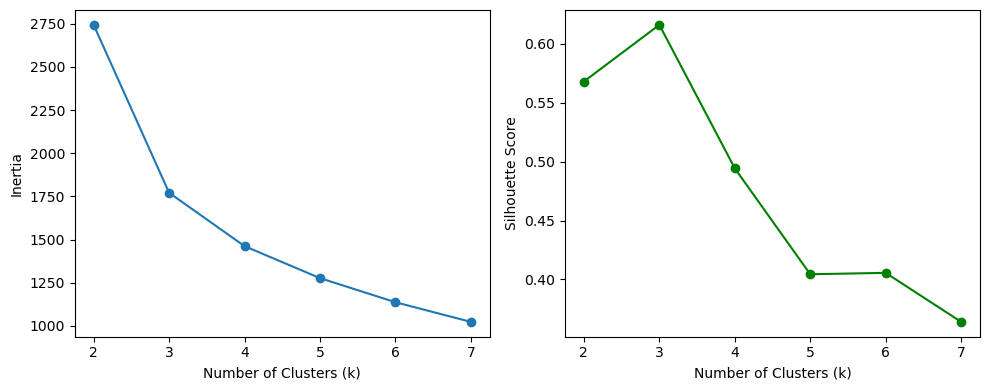


K-Means Silhouette Score (k=3): 0.614

STRUCTURAL CLUSTER MEDIAN PROPERTIES:
                    nser_w1  nser_w3  size_ratio
Structural Cluster                              
0                     2.946    2.973      -0.115
1                     1.008    0.559      -0.033
2                     0.860    3.187       1.273

FRACTION OF GALAXIES IN EACH ENVIRONMENT:
                    field_only  rg_only  cluster_only
Structural Cluster                                   
0                        0.398    0.284         0.318
1                        0.607    0.230         0.163
2                        0.607    0.164         0.229


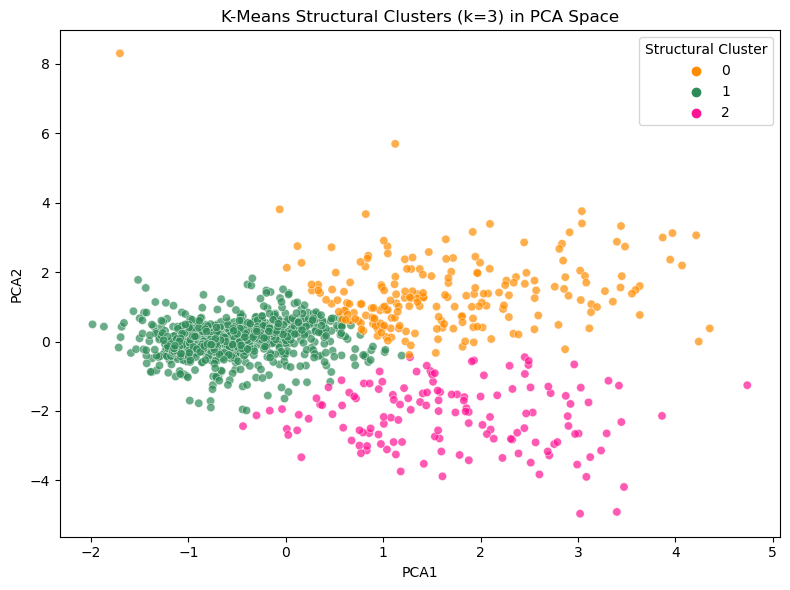

/var/folders/gx/q5wqxlgs0rgfm6f87vgxlgyw4s52w0/T/ipykernel_15352/813625214.py:95: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


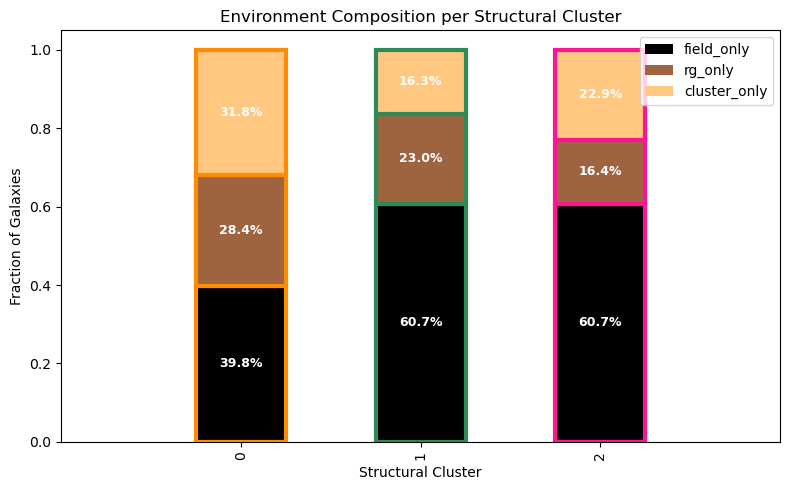

In [288]:
cluster_colors = ['darkorange','seagreen','deeppink']


# ----- STRUCTURAL FEATURES -----
#features = ['nser_w1', 'nser_w3', 'ba_w1', 'size_ratio']
features = ['nser_w1', 'nser_w3', 'size_ratio']#, 'mag_w1', 'mag_w3']
df = df.dropna(subset=features)

# ----- SCALE FEATURES -----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# ----- PCA -----
#pca = PCA(n_components=2)
#X_pca = pca.fit_transform(X_scaled)
df[['PCA1', 'PCA2']] = X_pca
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print("Total variance explained:", np.round(pca.explained_variance_ratio_.sum(), 3))

# ----- DETERMINE OPTIMAL K -----
inertias, silhouettes = [], []
K = range(2, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(K, inertias, 'o-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1,2,2)
plt.plot(K, silhouettes, 'o-', color='green')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# ----- CHOOSE K -----
k_opt = 3  # adjust if you prefer
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df['Structural Cluster'] = kmeans.fit_predict(X_pca)
sil_score = silhouette_score(X_pca, df['Structural Cluster'])
print(f"\nK-Means Silhouette Score (k={k_opt}): {sil_score:.3f}")

# ----- CLUSTER MEANS -----
cluster_summary = df.groupby('Structural Cluster')[features].median().round(3)
print("\nSTRUCTURAL CLUSTER MEDIAN PROPERTIES:")
print(cluster_summary)

# ----- ENVIRONMENT DISTRIBUTION -----
env_flags = ['field_only','rg_only','cluster_only']
env_summary = df.groupby('Structural Cluster')[env_flags].mean().round(3)
print("\nFRACTION OF GALAXIES IN EACH ENVIRONMENT:")
print(env_summary)

# ----- PCA PLOT -----
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Structural Cluster',
                palette=cluster_colors, alpha=0.7, edgecolor='w', linewidth=0.4)
plt.title(f'K-Means Structural Clusters (k={k_opt}) in PCA Space')
plt.tight_layout()
plt.show()

# ----- ENVIRONMENT STACKED BAR PLOT -----
ax = env_summary.plot(kind='bar', stacked=True, colormap='copper', figsize=(8,5))
plt.ylabel('Fraction of Galaxies')
plt.title('Environment Composition per Structural Cluster')

#cheeky approach to add edge colors
for container in ax.containers:
    for i, patch in enumerate(container.patches):
        color = cluster_colors[i]
        patch.set_edgecolor(color)  
        patch.set_linewidth(3)

#add percentage labels inside bars
for i, cluster_idx in enumerate(env_summary.index):
    cumulative = 0
    for env in env_flags:
        value = env_summary.loc[cluster_idx, env]
        ax.text(i, cumulative + value/2,
                f"{value*100:.1f}%", ha='center', va='center', color='white', 
                fontsize=9, fontweight='bold')
        cumulative += value
        
legend = plt.legend(loc='upper right')

ax.set_xlim(-1,3)

#now remove the edgecolors from the legend
for handle in legend.legendHandles:
    if isinstance(handle, Patch):
        handle.set_edgecolor('none')

plt.tight_layout()
plt.show()


In [2]:
#from galfit_kmeans import galfit_kmeans
from galfit_kmeans import *

#set colors=False to use the default GALFIT set of features (Sersic index, effective radius)
#df_scaled = galfit_kmeans(colors=False)

#colors=True will include the following color magnitudes from JM's SGA2020 photometry:
    #NUV - r
    #W1 - W3
#df_scaled = galfit_kmeans(colors=False)